In [6]:
library(tidyverse)

In [2]:
identify_significant_up_and_down_DEGs <- function(DEG_df) {
  num_up_DEGs <- DEG_df %>%
    dplyr::filter(significant == "True" & log2FoldChange > 0) %>%
    nrow()
  
  num_down_DEGs <- DEG_df %>%
    dplyr::filter(significant == "True" & log2FoldChange < 0) %>%
    nrow()
  
  return(c(num_up_DEGs, num_down_DEGs))
}

In [8]:
cell_types <- c("Cardiomyocyte", "Endothelial", "Fibroblast", "Myeloid", "Pericyte")

sex_DEG_up_list <- c()
sex_DEG_down_list <- c()
age_DEG_up_list <- c()
age_DEG_down_list <- c()
disease_DEG_up_list <- c()
disease_DEG_down_list <- c()
fetal_DEG_up_list <- c()
fetal_DEG_down_list <- c()

for (cell_type in cell_types) {
    # age: old vs young
    age_df <- read.csv(paste0("pydeseq2_results/", cell_type, "_age_group_old_vs_young_results.csv"), row.names = 1)
    age_counts <- identify_significant_up_and_down_DEGs(age_df)
    age_DEG_up_list <- c(age_DEG_up_list, age_counts[1])
    age_DEG_down_list <- c(age_DEG_down_list, age_counts[2])
  
    # sex: male vs female
    sex_df <- read.csv(paste0("pydeseq2_results/", cell_type, "_sex_male_vs_female_results.csv"), row.names = 1)
    sex_counts <- identify_significant_up_and_down_DEGs(sex_df)
    sex_DEG_up_list <- c(sex_DEG_up_list, sex_counts[1])
    sex_DEG_down_list <- c(sex_DEG_down_list, sex_counts[2])

    # disease: Y vs N
    disease_df <- read.csv(paste0("pydeseq2_results/", cell_type, "_disease_binary_Y_vs_N_results.csv"), row.names = 1)
    disease_counts <- identify_significant_up_and_down_DEGs(disease_df)
    disease_DEG_up_list <- c(disease_DEG_up_list, disease_counts[1])
    disease_DEG_down_list <- c(disease_DEG_down_list, disease_counts[2])

    # fetal vs young
    fetal_df <- read.csv(paste0("pydeseq2_results/", cell_type, "_age_group_fetal_vs_young_results.csv"), row.names = 1)
    fetal_counts <- identify_significant_up_and_down_DEGs(fetal_df)
    fetal_DEG_up_list <- c(fetal_DEG_up_list, fetal_counts[1])
    fetal_DEG_down_list <- c(fetal_DEG_down_list, fetal_counts[2])
}

# construct data frames for each comparison
age_deg_df <- data.frame(
  cell_type = rep(cell_types, each = 2),
  DEG = c(age_DEG_up_list, age_DEG_down_list),
  direction = rep(c("up", "down"), times = length(cell_types)),
  comparison = "Age (old vs young)"
)

sex_deg_df <- data.frame(
  cell_type = rep(cell_types, each = 2),
  DEG = c(sex_DEG_up_list, sex_DEG_down_list),
  direction = rep(c("up", "down"), times = length(cell_types)),
  comparison = "Sex (male vs female)"
)

disease_deg_df <- data.frame(
  cell_type = rep(cell_types, each = 2),
  DEG = c(disease_DEG_up_list, disease_DEG_down_list),
  direction = rep(c("up", "down"), times = length(cell_types)),
  comparison = "Disease (Y vs N)"
)

fetal_deg_df <- data.frame(
  cell_type = rep(cell_types, each = 2),
  DEG = c(fetal_DEG_up_list, fetal_DEG_down_list),
  direction = rep(c("up", "down"), times = length(cell_types)),
  comparison = "Fetal vs Young"
)

# Combine all into one master dataframe
all_deg_df <- rbind(age_deg_df, sex_deg_df, disease_deg_df, fetal_deg_df)

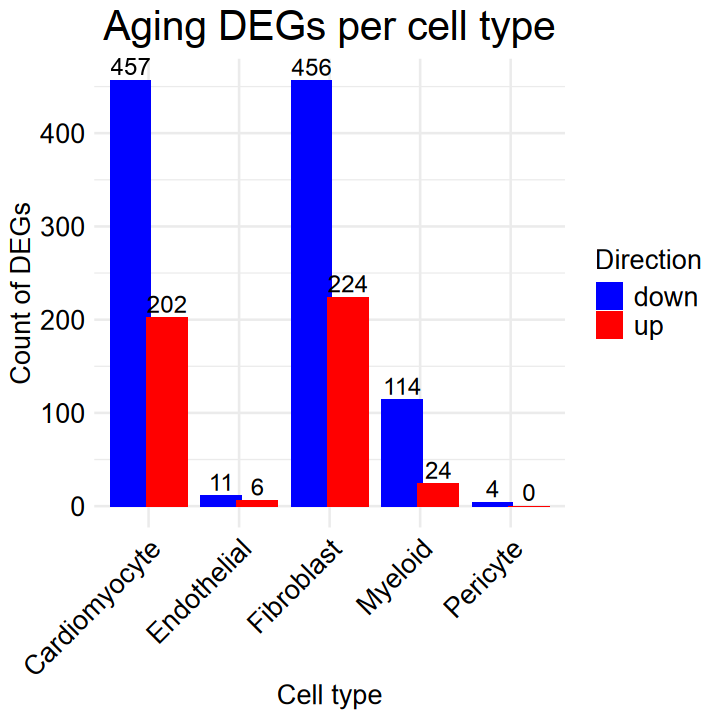

In [9]:
options(repr.plot.width = 6, repr.plot.height = 6)

# combine up and down into one dataframe
concat_age_df <- bind_rows(age_deg_down_df, age_deg_up_df)

# plot
p1 <- ggplot(concat_age_df, aes(x = cell_type, y = DEG, fill = direction)) +
  geom_col(position = position_dodge(width = 0.8)) +
  geom_text(aes(label = DEG),
            position = position_dodge(width = 0.8),
            vjust = -0.3, size = 5) +
  scale_fill_manual(values = c("up" = "red", "down" = "blue")) +
  labs(
    x = "Cell type",
    y = "Count of DEGs",
    title = "Aging DEGs per cell type",
    fill = "Direction"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(p1, filename = "02C_num_aging_DAR_per_cell_type.pdf", width = 6, height = 6)

p1

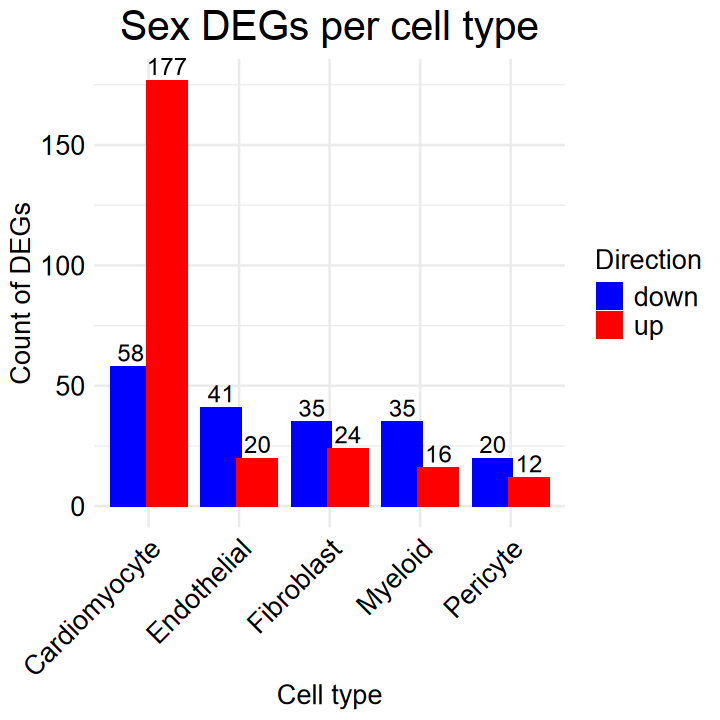

In [16]:
options(repr.plot.width = 6, repr.plot.height = 6)

# combine up and down into one dataframe
concat_age_df <- bind_rows(sex_deg_down_df, sex_deg_up_df)

# plot
p2 <- ggplot(concat_age_df, aes(x = cell_type, y = DEG, fill = direction)) +
  geom_col(position = position_dodge(width = 0.8)) +
  geom_text(aes(label = DEG),
            position = position_dodge(width = 0.8),
            vjust = -0.3, size = 5) +
  scale_fill_manual(values = c("up" = "red", "down" = "blue")) +
  labs(
    x = "Cell type",
    y = "Count of DEGs",
    title = "Sex DEGs per cell type",
    fill = "Direction"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(p2, filename = "02C_num_sex_DAR_per_cell_type.pdf", width = 6, height = 6)

p2

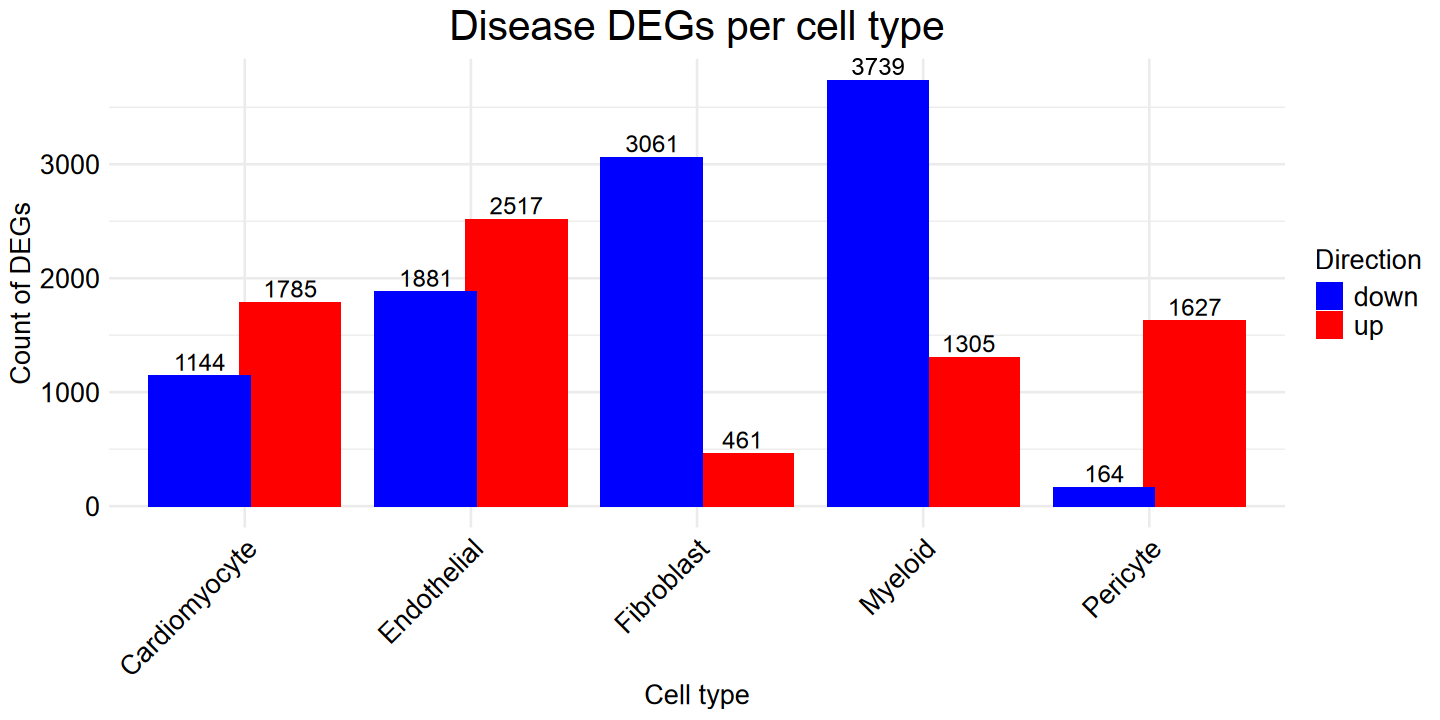

In [19]:
options(repr.plot.width = 12, repr.plot.height = 6)

# plot
p3 <- ggplot(disease_deg_df, aes(x = cell_type, y = DEG, fill = direction)) +
  geom_col(position = position_dodge(width = 0.8)) +
  geom_text(aes(label = DEG),
            position = position_dodge(width = 0.8),
            vjust = -0.3, size = 5) +
  scale_fill_manual(values = c("up" = "red", "down" = "blue")) +
  labs(
    x = "Cell type",
    y = "Count of DEGs",
    title = "Disease DEGs per cell type",
    fill = "Direction"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(p3, filename = "02C_num_disease_DAR_per_cell_type.pdf", width = 12, height = 6)

p3

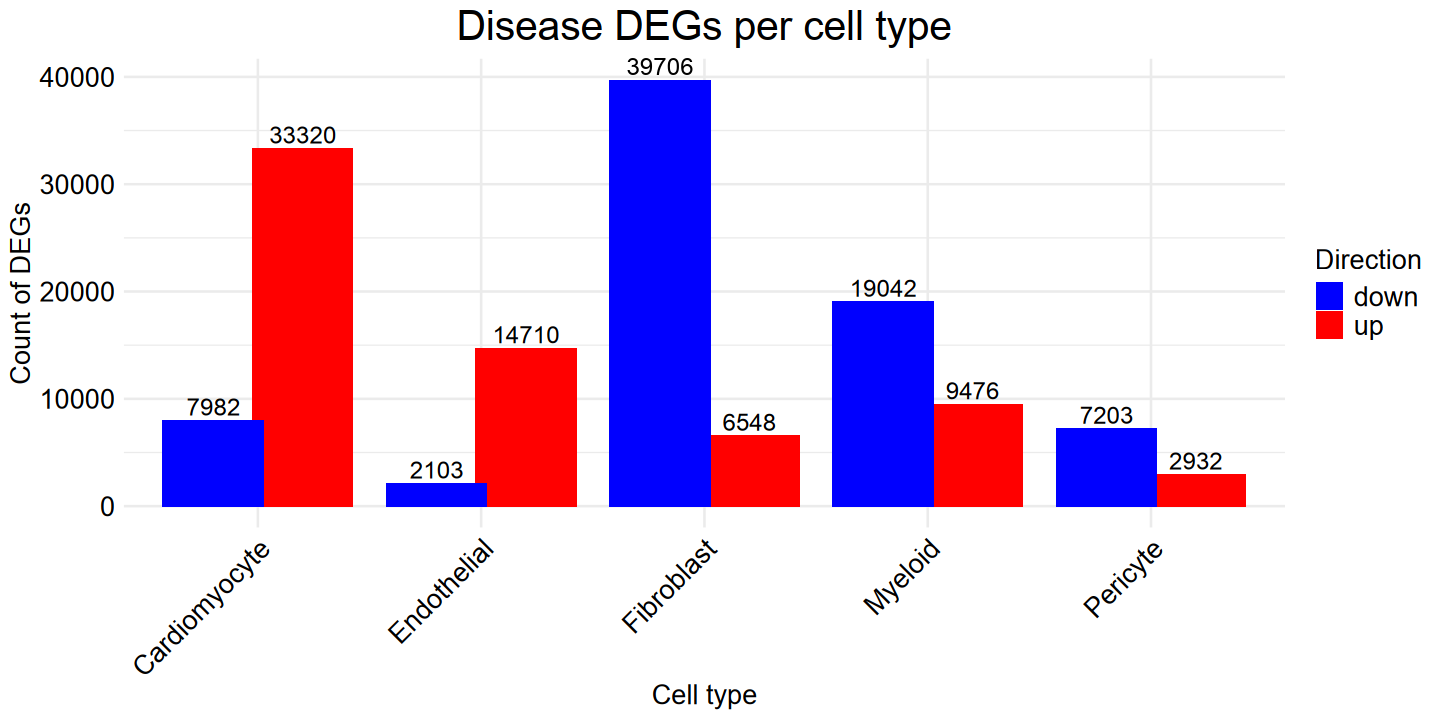

In [20]:
options(repr.plot.width = 12, repr.plot.height = 6)

# plot
p4 <- ggplot(fetal_deg_df, aes(x = cell_type, y = DEG, fill = direction)) +
  geom_col(position = position_dodge(width = 0.8)) +
  geom_text(aes(label = DEG),
            position = position_dodge(width = 0.8),
            vjust = -0.3, size = 5) +
  scale_fill_manual(values = c("up" = "red", "down" = "blue")) +
  labs(
    x = "Cell type",
    y = "Count of DEGs",
    title = "Disease DEGs per cell type",
    fill = "Direction"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(p4, filename = "02C_num_development_DAR_per_cell_type.pdf", width = 12, height = 6)

p4